In [71]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('/zhome/71/c/146676/main/')
import SimpleITK as sitk
import loader_XA_to_NA
import importlib
importlib.reload(loader_XA_to_NA)
import tifffile

In [72]:
xray_slices = range(500,900)
neutron_slices = range(1100,1300)
output_volume = [[1100,1300],[None], [None]]
reg = loader_XA_to_NA.load_subset_of_registered_data(dataset='tv', h=1.5, xray_slices = xray_slices,
    neutron_slices = neutron_slices, output_volume = output_volume)

Resampling the transformation
Resampling moving image


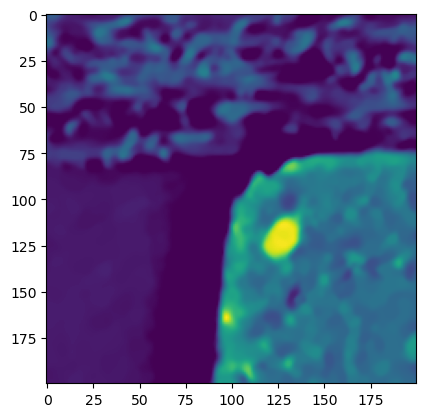

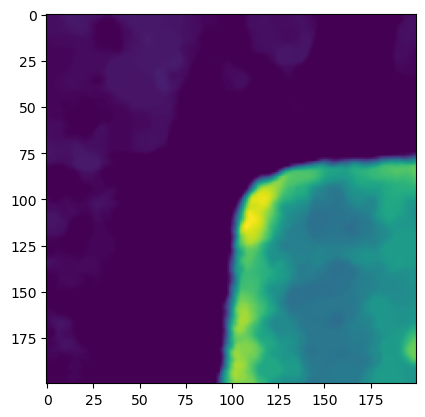

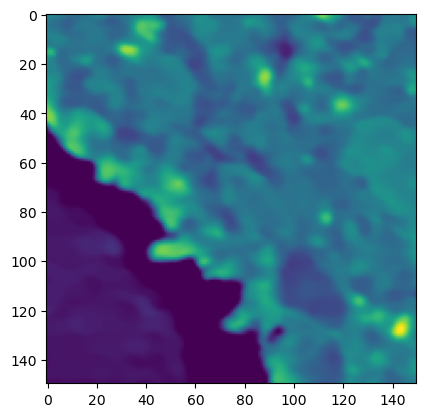

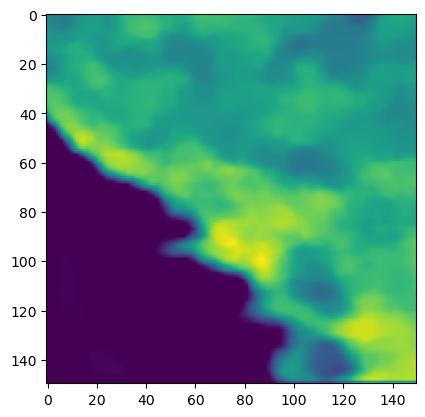

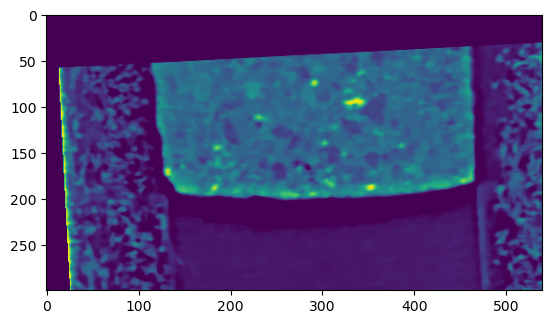

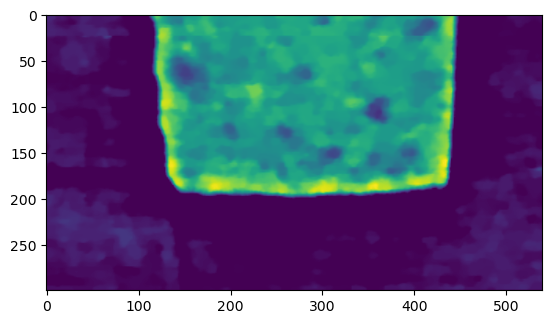

In [74]:
fixed = sitk.GetArrayFromImage(reg.fixed)
moving = sitk.GetArrayFromImage(reg.moving)
plt.imshow(moving[150,50:250,600:800])
plt.show()
plt.imshow(fixed[150,50:250,600:800])
plt.show()
plt.imshow(moving[150:300,150,750:900])
plt.show()
plt.imshow(fixed[150:300,150,750:900])
plt.show()
plt.imshow(moving[:,:,750])
plt.show()
plt.imshow(fixed[:,:,750])
plt.show()

In [ ]:
nz, ny, nx = np.shape(moving)
from cil.framework import ImageGeometry, ImageData
from cil.optimisation.operators import GradientOperator
ig = ImageGeometry(voxel_num_x=nx, voxel_num_y=ny, voxel_num_z=nz)
im_subset_ID = ImageData(moving, geometry=ig)
def xi_vector_field(image,eta):
    G = GradientOperator(ig)
    numerator = G.direct(image)
    denominator = np.sqrt(eta**2 + numerator.get_item(0)**2 + numerator.get_item(1)**2)
    xi = numerator/denominator

    return (xi.get_item(0)**2 + xi.get_item(1)**2).sqrt()


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 25))  # 1 row, 3 columns
fig.patch.set_facecolor('black')  # Set the background color to black
im1 = axes[0,0].imshow(im_subset[:,5])
axes[0,0].axis('off')
grad_im = xi_vector_field(im_subset_ID, 0.005)
im2 = axes[0,1].imshow(grad_im.as_array()[:,5])
axes[0,1].axis('off')
grad_im = xi_vector_field(im_subset_ID, 0.001)
im2 = axes[1,0].imshow(grad_im.as_array()[:,5])
axes[1,0].axis('off')
grad_im = xi_vector_field(im_subset_ID, 0.002)
im2 = axes[1,1].imshow(grad_im.as_array()[:,5])
axes[1,1].axis('off')